# Section 4 figures for the kick-off report

Generates the **4 placeholder figures** in `Section4_General_Statistics.docx` and prints the numbers for the **yellow blanks** in the text.

| Figure | Output file | What it shows |
|---|---|---|
| 4.2 | `fig4_2_coverage.png` | Households reporting per month, Std vs ToU |
| 4.3 | `fig4_3_incomplete_days.png` | % of household-days with fewer than 48 readings, split into first/last days and all other days |
| 4.6 | `fig4_6_acorn_tariff.png` | dToU share by ACORN group, household-level chi-square and block-level permutation test |
| 4.8 | `fig4_8_kwh_hist.png` | Half-hourly kWh histogram (10% of households from every block) |

## How to use
1. **Step 1:** if the dataset is already on this computer, put its folder in `DATA_DIR`. Leave it as `None` to use the kagglehub cache (downloads the dataset the first time; needs a Kaggle API token). `OUT_DIR` sets where the PNGs are saved.
2. **Restart the kernel, then Run All.** Step 2 checks the packages and upgrades them if needed. This fixes the *"A module that was compiled using NumPy 1.x cannot be run in NumPy 2.x"* error.
3. Replace each PLACEHOLDER box in the Word file with the matching PNG from `OUT_DIR`.
4. Copy the numbers from the last cell into the yellow blanks (`X`, `Y`, `X2`, `Y2`, `Q1`, `MEDIAN`, `Q3`).

Runtime: Steps 4 and 5 take about a minute. Step 6 reads all 112 half-hourly files one at a time (a few minutes, low memory).

## Step 1: Settings

In [1]:
# Folder that contains informations_households.csv (a parent folder also works).
# Example: DATA_DIR = r"D:\data\smart-meters-in-london"
DATA_DIR = None

# Where the PNGs and numbers_for_report.txt are written. A relative path is resolved
# against the notebook's working directory (normally the folder the notebook is in).
OUT_DIR = "section4_figures"

SAMPLE_FRAC = 0.10   # share of households per block file used for Fig 4.8
SEED = 431

# Coverage rule, report Section 5.1
USABLE_READINGS = 44         # a day is usable with at least this many of its 48 half-hourly readings
COVERAGE_MIN = 0.90          # share of usable days needed: over a household's own 2013 period, and within a 2012 month
MIN_USABLE_MONTHS_2012 = 6   # usable 2012 months needed for the year-over-year subset


## Step 2: Environment check

NumPy 2.x needs **matplotlib >= 3.9** and **pandas >= 2.2.2**. This cell upgrades older copies with the kernel's own Python, so the packages land in the environment the notebook actually uses.

In [2]:
import importlib.util
import os
import re
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version


def installed(pkg):
    try:
        return version(pkg)
    except PackageNotFoundError:
        return None


def older_than(pkg, minimum):
    v = installed(pkg)
    if v is None:
        return True
    nums = tuple(int(m.group()) for part in v.split(".")[:3] if (m := re.match(r"\d+", part)))
    return nums < minimum


needs = [spec for pkg, minimum, spec in [("matplotlib", (3, 9), "matplotlib>=3.9"),
                                         ("pandas", (2, 2, 2), "pandas>=2.2.2")]
         if older_than(pkg, minimum)]
if DATA_DIR is None and not os.environ.get("SMART_METER_DIR") and installed("kagglehub") is None:
    needs.append("kagglehub")

print("Python:", sys.executable)
for pkg in ["numpy", "pandas", "matplotlib", "kagglehub"]:
    print(f"  {pkg:<11} {installed(pkg) or 'not installed'}")

if needs:
    print("\nInstalling / upgrading:", ", ".join(needs))
    if importlib.util.find_spec("pip") is None:
        # uv-created virtualenvs ship without pip, so `python -m pip` would fail with a cryptic error.
        raise RuntimeError(f"Need {needs}, but this Python has no pip. Install them with your own tool "
                           f"(for uv: uv pip install --python \"{sys.executable}\" {' '.join(needs)}), "
                           "then restart the kernel and Run All again.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *needs])
    stale = sorted({m.split(".")[0] for m in sys.modules} & {"matplotlib", "pandas"})
    if stale:
        raise RuntimeError(f"Upgraded {needs}, but an old copy of {stale} is already loaded. "
                           "Restart the kernel, then Run All again.")
    print("Upgrade finished. Continuing with the new versions.")
else:
    print("\nAll packages OK.")

Python: E:\BigDataProj\.venv\Scripts\python.exe
  numpy       2.2.6
  pandas      3.0.5
  matplotlib  3.10.0
  kagglehub   1.0.2

All packages OK.


In [3]:
import importlib

importlib.invalidate_caches()
try:
    import math
    from pathlib import Path

    import matplotlib.pyplot as plt
    import numpy as np
    import numpy.random  # noqa: F401  (numpy 2.x loads this lazily, so a blocked build only fails here)
    import pandas as pd
except (ImportError, AttributeError) as err:
    if "Application Control" in str(err):
        hint = ("A Windows Application Control policy blocked a native library file, so a restart will not "
                "help. Install an older numpy / matplotlib build (see requirements.txt), then restart.")
    else:
        hint = "Restart the kernel, then Run All again."
    raise RuntimeError(f"Import failed. {hint} Original error: {err}") from err

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {plt.matplotlib.__version__}")

STD, TOU = "#5B7C99", "#E07A3F"
EDGE = "#B8B8B8"  # first/last household day in Fig 4.3
GROUPS = ["Affluent", "Comfortable", "Adversity"]
GROUP_COL = {"Affluent": "#3A7D44", "Comfortable": "#D9A441", "Adversity": "#B5473A"}
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 11})

numpy 2.2.6 | pandas 3.0.5 | matplotlib 3.10.0


## Step 3: Load dataset

In [4]:
def resolve_dataset_dir():
    source = DATA_DIR or os.environ.get("SMART_METER_DIR")
    if source:
        root = Path(source).expanduser()
        if not root.exists():
            raise FileNotFoundError(f"DATA_DIR does not exist: {root}")
    else:
        import kagglehub
        root = Path(kagglehub.dataset_download("jeanmidev/smart-meters-in-london"))
    if (root / "informations_households.csv").exists():
        return root
    hits = sorted(root.rglob("informations_households.csv"))
    if not hits:
        raise FileNotFoundError(f"informations_households.csv not found anywhere under {root}")
    return hits[0].parent


dataset_dir = resolve_dataset_dir()
OUT = Path(OUT_DIR).expanduser()
OUT.mkdir(parents=True, exist_ok=True)
report = {}  # values for the yellow blanks in the report

households = pd.read_csv(dataset_dir / "informations_households.csv")
print(f"Dataset directory: {dataset_dir}")
print(f"Households: {len(households):,}")
print(f"Figures will be saved to: {OUT.resolve()}")

Dataset directory: C:\Users\purin\.cache\kagglehub\datasets\jeanmidev\smart-meters-in-london\versions\21
Households: 5,566
Figures will be saved to: E:\BigDataProj\src\section4_figures


## Step 4: Daily layer, coverage and incomplete days (Figs 4.2, 4.3)

In [5]:
cols = ["LCLid", "day", "energy_count"]
daily_csv = dataset_dir / "daily_dataset.csv"
if daily_csv.exists():
    daily = pd.read_csv(daily_csv, usecols=cols)
else:  # fall back to the 112 block files
    daily = pd.concat([pd.read_csv(f, usecols=cols)
                       for f in sorted((dataset_dir / "daily_dataset").rglob("block_*.csv"))],
                      ignore_index=True)
daily["day"] = pd.to_datetime(daily["day"])
daily = daily.merge(households[["LCLid", "stdorToU"]], on="LCLid", how="left")
daily["month"] = daily["day"].dt.to_period("M").dt.to_timestamp()
print(f"{len(daily):,} household-days, {daily['day'].min():%d %b %Y} to {daily['day'].max():%d %b %Y}")

3,510,433 household-days, 23 Nov 2011 to 28 Feb 2014


### Fig 4.2 Households reporting per month

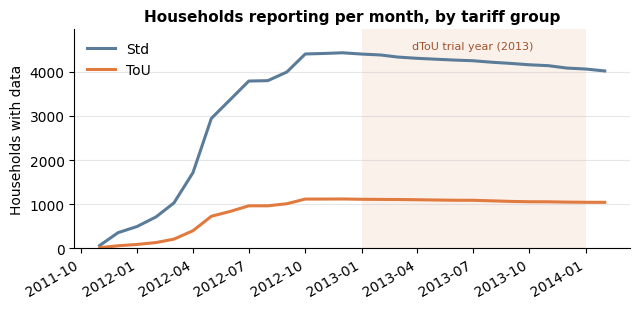

In [6]:
coverage = (daily.groupby(["month", "stdorToU"])["LCLid"].nunique()
            .unstack("stdorToU").reindex(columns=["Std", "ToU"]).fillna(0))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.axvspan(pd.Timestamp("2013-01-01"), pd.Timestamp("2014-01-01"), color=TOU, alpha=0.10, lw=0)
ax.plot(coverage.index, coverage["Std"], color=STD, lw=2.2, label="Std")
ax.plot(coverage.index, coverage["ToU"], color=TOU, lw=2.2, label="ToU")
ax.text(pd.Timestamp("2013-07-01"), coverage.values.max() * 1.02, "dToU trial year (2013)",
        ha="center", fontsize=8, color="#A0522D")
ax.set_ylim(0, coverage.values.max() * 1.12)
ax.set_ylabel("Households with data")
ax.set_title("Households reporting per month, by tariff group")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "fig4_2_coverage.png", dpi=200)
plt.show()

### Fig 4.3 Household-days with fewer than 48 readings

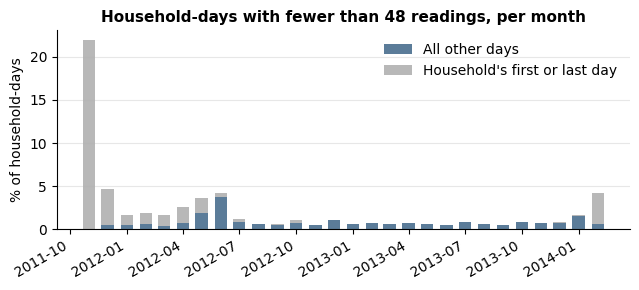

Incomplete household-days: 41,081 of 3,510,433 (1.17%)
  on a household's first or last day: 11,018 (26.8% of incomplete days)
  on all other days: 30,063 (0.86% of those 3,499,306 days)
Household-days with 0 readings: 30
Worst month, all days: Nov 2011 (22.0%) (partial start-up month, 346 household-days)
Worst month, excluding first/last days: Jun 2012 (3.75%)
Five worst days, excluding first/last days (% of households reporting that day):
day
2012-06-13    18.7%
2012-06-14    19.6%
2012-06-15    21.2%
2012-06-16    23.1%
2012-06-17    19.8%


Calendar days absent inside households' reporting spans: 4,088 (households with a gap: 733)


In [7]:
# A household's first and last day are partial by construction (metering starts or stops mid-day),
# so they are split out from days that are incomplete for other reasons.
daily["incomplete"] = daily["energy_count"] < 48
first_day = daily.groupby("LCLid")["day"].transform("min")
last_day = daily.groupby("LCLid")["day"].transform("max")
daily["edge_day"] = (daily["day"] == first_day) | (daily["day"] == last_day)
daily["inc_edge"] = daily["incomplete"] & daily["edge_day"]
daily["inc_inner"] = daily["incomplete"] & ~daily["edge_day"]
pct = daily.groupby("month")[["inc_inner", "inc_edge"]].mean() * 100

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.bar(pct.index, pct["inc_inner"], width=20, color=STD, label="All other days")
ax.bar(pct.index, pct["inc_edge"], width=20, bottom=pct["inc_inner"], color=EDGE,
       label="Household's first or last day")
ax.set_ylabel("% of household-days")
ax.set_title("Household-days with fewer than 48 readings, per month")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "fig4_3_incomplete_days.png", dpi=200)
plt.show()

n_incomplete = int(daily["incomplete"].sum())
n_edge = int(daily["inc_edge"].sum())
n_inner = int(daily["inc_inner"].sum())
n_inner_days = int((~daily["edge_day"]).sum())
n_zero = int((daily["energy_count"] == 0).sum())
print(f"Incomplete household-days: {n_incomplete:,} of {len(daily):,} ({n_incomplete / len(daily):.2%})")
print(f"  on a household's first or last day: {n_edge:,} ({n_edge / n_incomplete:.1%} of incomplete days)")
print(f"  on all other days: {n_inner:,} ({n_inner / n_inner_days:.2%} of those {n_inner_days:,} days)")
print(f"Household-days with 0 readings: {n_zero:,}")

total_pct = pct.sum(axis=1)
print(f"Worst month, all days: {total_pct.idxmax():%b %Y} ({total_pct.max():.1f}%)"
      f" (partial start-up month, {int((daily['month'] == total_pct.idxmax()).sum()):,} household-days)")
print(f"Worst month, excluding first/last days: {pct['inc_inner'].idxmax():%b %Y} ({pct['inc_inner'].max():.2f}%)")

inner_days = daily[~daily["edge_day"]].groupby("day")["incomplete"].mean() * 100
print("Five worst days, excluding first/last days (% of households reporting that day):")
print(inner_days.nlargest(5).sort_index().map("{:.1f}%".format).to_string())

# Missing rows are invisible to the figure above (it only counts days that exist).
gaps = daily.sort_values(["LCLid", "day"]).groupby("LCLid")["day"].diff().dt.days - 1
print(f"Calendar days absent inside households' reporting spans: {int(gaps.clip(lower=0).sum()):,}"
      f" (households with a gap: {int(daily.loc[gaps[gaps > 0].index, 'LCLid'].nunique()):,})")

### Coverage rule from report Section 5.1 (fills `X`, `Y`, `X2`, `Y2`)

A day is usable with at least 44 of its 48 half-hourly readings. A calendar day with no row in the daily layer counts as unusable.

- **2013 (`X2`, `Y2`):** at least 90% of the calendar days in the household's own recorded period within 2013 (first to last record day, clipped to 2013) are usable. Households recruited after 1 January 2012, or that stopped reporting during 2013, are not penalised for days outside their own period.
- **Both years (`X`, `Y`):** the 2013 rule plus at least 6 usable months in 2012. The report does not define a usable month; here it is a month in which at least 90% of the calendar days are usable, matching the other thresholds.

In [8]:
daily["usable"] = daily["energy_count"] >= USABLE_READINGS
span = daily.groupby("LCLid")["day"].agg(start="min", end="max")

# 2013: usable days over the calendar days of the household's own recorded period inside 2013.
start_2013 = span["start"].clip(lower=pd.Timestamp("2013-01-01"))
end_2013 = span["end"].clip(upper=pd.Timestamp("2013-12-31"))
days_2013 = ((end_2013 - start_2013).dt.days + 1).clip(lower=0)  # 0 when the household has no 2013 period
usable_2013 = (daily[daily["day"].dt.year == 2013].groupby("LCLid")["usable"].sum()
               .reindex(span.index).fillna(0))
ok_2013 = usable_2013 / days_2013.where(days_2013 > 0) >= COVERAGE_MIN

# 2012: a month is usable when at least COVERAGE_MIN of its calendar days are usable.
in_2012 = daily[daily["day"].dt.year == 2012]
usable_days_2012 = (in_2012.groupby(["LCLid", in_2012["day"].dt.month])["usable"].sum()
                    .unstack().reindex(columns=range(1, 13)).fillna(0))
days_in_month = pd.Series([pd.Period(f"2012-{m:02d}").days_in_month for m in range(1, 13)],
                          index=range(1, 13))
usable_months_2012 = ((usable_days_2012 / days_in_month) >= COVERAGE_MIN).sum(axis=1).reindex(span.index).fillna(0)
ok_both = ok_2013 & (usable_months_2012 >= MIN_USABLE_MONTHS_2012)

flags = (pd.DataFrame({"ok_2013": ok_2013, "ok_both": ok_both})
         .reindex(households["LCLid"]).fillna(False).astype(bool)
         .join(households.set_index("LCLid")["stdorToU"]))
counts = flags.groupby("stdorToU")[["ok_both", "ok_2013"]].sum().astype(int)
counts["total"] = households["stdorToU"].value_counts()

report["X  (Std, both 2012 and 2013)"] = int(counts.loc["Std", "ok_both"])
report["Y  (ToU, both 2012 and 2013)"] = int(counts.loc["ToU", "ok_both"])
report["X2 (Std, 2013)"] = int(counts.loc["Std", "ok_2013"])
report["Y2 (ToU, 2013)"] = int(counts.loc["ToU", "ok_2013"])
report["Usable-month rule (2012)"] = (f">= {COVERAGE_MIN:.0%} of calendar days usable (>= {USABLE_READINGS}/48 readings); "
                                      f">= {MIN_USABLE_MONTHS_2012} such months")
counts


,ok_both,ok_2013,total
stdorToU,,,
Std,3356,4387,4443
ToU,835,1111,1123


In [9]:
del daily, in_2012, usable_days_2012, flags  # free memory before Step 6

## Step 5: Fig 4.6 dToU share by ACORN group

Recomputes the household-level chi-square test from the report's Section 6 so the two sections agree. The 51 unclassified households (ACORN-U or blank) are excluded.

That test treats every household as an independent draw. The data does not support this: block files hold one ACORN group each (almost always) and the dToU share varies between blocks far more than chance allows. A second test therefore uses each block file as one unit (permutation test, group labels shuffled across blocks). Both results are reported; the block-level one is the more cautious.

109 single-group blocks of 111 (Affluent 43, Comfortable 30, Adversity 36)
Spread of dToU share between blocks: sd 15.9 points observed, 5.7 expected if households were independent
Mean block dToU share: Affluent 21.9%, Comfortable 21.5%, Adversity 16.4%
Block-level permutation test, three groups: p = 0.267
Block-level permutation test, Adversity vs the other two (-5.3 points): p = 0.107


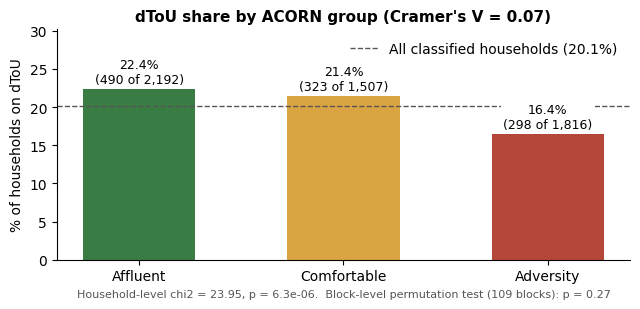

stdorToU,Std,ToU
Acorn_grouped,,
Affluent,1702,490
Comfortable,1184,323
Adversity,1518,298


In [10]:
classified = households[households["Acorn_grouped"].isin(GROUPS)]
n_unclassified = len(households) - len(classified)
table = pd.crosstab(classified["Acorn_grouped"], classified["stdorToU"]).reindex(GROUPS)
n_classified = int(table.values.sum())
expected_counts = np.outer(table.sum(axis=1), table.sum(axis=0)) / n_classified
chi2 = float(((table.values - expected_counts) ** 2 / expected_counts).sum())
dof = (table.shape[0] - 1) * (table.shape[1] - 1)
assert dof == 2, "the p-value shortcut below is exact only for df = 2"
p_value = math.exp(-chi2 / 2)  # chi-square survival function for df = 2
cramers_v = math.sqrt(chi2 / n_classified)  # min(rows - 1, cols - 1) = 1 for a 3 x 2 table
share = table["ToU"] / table.sum(axis=1) * 100
overall = table["ToU"].sum() / n_classified * 100

# Block-level check: one observation per block file instead of per household.
# Blocks that mix ACORN groups cannot be assigned to a group, so they are left out.
blocks = (classified.assign(tou=classified["stdorToU"].eq("ToU"))
          .groupby("file").agg(n=("tou", "size"), tou=("tou", "mean"),
                               n_groups=("Acorn_grouped", "nunique"),
                               group=("Acorn_grouped", lambda s: s.mode()[0])))
blocks = blocks[blocks["n_groups"] == 1]
tou_block = blocks["tou"].to_numpy()
code = blocks["group"].map({g: i for i, g in enumerate(GROUPS)}).to_numpy()
p_all = table["ToU"].sum() / n_classified
sd_observed = tou_block.std(ddof=1) * 100
sd_expected = math.sqrt((p_all * (1 - p_all) / blocks["n"]).mean()) * 100  # if households were independent


def between_group_ss(c):
    counts = np.bincount(c, minlength=len(GROUPS))
    sums = np.bincount(c, weights=tou_block, minlength=len(GROUPS))
    return float((counts * (sums / counts - tou_block.mean()) ** 2).sum())


N_PERM = 20_000
rng = np.random.default_rng(SEED)
observed_ss = between_group_ss(code)
perm_ss = np.array([between_group_ss(rng.permutation(code)) for _ in range(N_PERM)])
p_block = (1 + int((perm_ss >= observed_ss).sum())) / (N_PERM + 1)
adv = code == GROUPS.index("Adversity")
diff_adv = tou_block[adv].mean() - tou_block[~adv].mean()
perm_diff = np.array([(lambda a: tou_block[a].mean() - tou_block[~a].mean())(rng.permutation(adv))
                      for _ in range(N_PERM)])
p_block_adv = (1 + int((np.abs(perm_diff) >= abs(diff_adv)).sum())) / (N_PERM + 1)
block_mean = blocks.groupby("group")["tou"].mean().reindex(GROUPS) * 100
print(f"{len(blocks)} single-group blocks of {classified['file'].nunique()} "
      f"({', '.join(f'{g} {int((blocks.group == g).sum())}' for g in GROUPS)})")
print(f"Spread of dToU share between blocks: sd {sd_observed:.1f} points observed, "
      f"{sd_expected:.1f} expected if households were independent")
print("Mean block dToU share: " + ", ".join(f"{g} {block_mean[g]:.1f}%" for g in GROUPS))
print(f"Block-level permutation test, three groups: p = {p_block:.3f}")
print(f"Block-level permutation test, Adversity vs the other two ({diff_adv * 100:+.1f} points): "
      f"p = {p_block_adv:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.bar(GROUPS, share.values, color=[GROUP_COL[g] for g in GROUPS], width=0.55)
ax.axhline(overall, color="#555", ls="--", lw=1, zorder=1, label=f"All classified households ({overall:.1f}%)")
for bar, g in zip(bars, GROUPS):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{share[g]:.1f}%\n({table.loc[g, 'ToU']:,} of {table.loc[g].sum():,})",
            ha="center", va="bottom", fontsize=9, zorder=3,
            bbox={"fc": "white", "ec": "none", "pad": 1.5})  # keeps the dashed line off the labels
ax.set_ylim(0, share.max() * 1.35)
ax.set_ylabel("% of households on dToU")
ax.set_title(f"dToU share by ACORN group (Cramer's V = {cramers_v:.2f})")
ax.set_xlabel(f"Household-level chi2 = {chi2:.2f}, p = {p_value:.1e}.  "
              f"Block-level permutation test ({len(blocks)} blocks): p = {p_block:.2f}",
              fontsize=8, color="#555")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUT / "fig4_6_acorn_tariff.png", dpi=200)
plt.show()

report["chi-square check"] = (", ".join(f"{g} {share[g]:.1f}% ToU" for g in GROUPS)
                              + f"; household-level chi2 = {chi2:.2f}, df = 2, p = {p_value:.2e}"
                              + f", Cramer's V = {cramers_v:.3f}")
report["block-level test"] = (f"{len(blocks)} blocks, mean block dToU share "
                              + ", ".join(f"{g} {block_mean[g]:.1f}%" for g in GROUPS)
                              + f"; permutation p = {p_block:.3f} (three groups), "
                              f"{p_block_adv:.3f} (Adversity vs others)")
report["ACORN unclassified (excluded)"] = n_unclassified
table

## Step 6: Fig 4.8 Half-hourly kWh distribution (fills `Q1`, `MEDIAN`, `Q3`)

Samples 10% of households **from every block file**. Block files group households by ACORN category, so a single block (like `block_0`) is not representative.

In [11]:
sample_ids = set(households.groupby("file", group_keys=False)
                 .sample(frac=SAMPLE_FRAC, random_state=SEED)["LCLid"])
block_files = sorted((dataset_dir / "halfhourly_dataset").rglob("block_*.csv"))
if not block_files:
    raise FileNotFoundError(f"No block_*.csv files under {dataset_dir / 'halfhourly_dataset'}")
print(f"{len(sample_ids):,} sampled households, {len(block_files)} block files")

chunks = []
for i, path in enumerate(block_files, 1):
    block = pd.read_csv(path, usecols=["LCLid", "energy(kWh/hh)"], na_values=["Null"])
    values = block.loc[block["LCLid"].isin(sample_ids), "energy(kWh/hh)"].dropna()
    chunks.append(values.to_numpy(dtype="float32"))
    if i % 16 == 0 or i == len(block_files):
        print(f"  read {i}/{len(block_files)} block files")
kwh = pd.Series(np.concatenate(chunks))
del chunks, block

557 sampled households, 112 block files


  read 16/112 block files


  read 32/112 block files


  read 48/112 block files


  read 64/112 block files


  read 80/112 block files


  read 96/112 block files


  read 112/112 block files


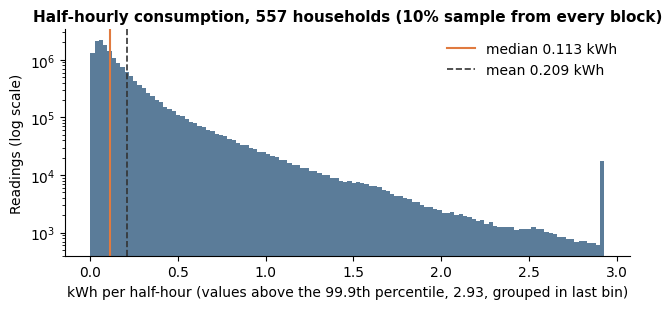

16,740,052 readings, mean 0.2087 kWh


In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
upper = float(kwh.quantile(0.999))
ax.hist(kwh.clip(upper=upper), bins=120, color=STD)
ax.set_yscale("log")
ax.axvline(kwh.median(), color=TOU, lw=1.5, label=f"median {kwh.median():.3f} kWh")
ax.axvline(kwh.mean(), color="#333", lw=1.2, ls="--", label=f"mean {kwh.mean():.3f} kWh")
ax.set_xlabel(f"kWh per half-hour (values above the 99.9th percentile, {upper:.2f}, grouped in last bin)")
ax.set_ylabel("Readings (log scale)")
ax.set_title(f"Half-hourly consumption, {len(sample_ids):,} households "
             f"({SAMPLE_FRAC:.0%} sample from every block)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / "fig4_8_kwh_hist.png", dpi=200)
plt.show()

q = kwh.quantile([0.25, 0.5, 0.75])
report["Q1"] = round(float(q[0.25]), 3)
report["MEDIAN"] = round(float(q[0.5]), 3)
report["Q3"] = round(float(q[0.75]), 3)
print(f"{len(kwh):,} readings, mean {kwh.mean():.4f} kWh")

## Step 7: Numbers for the report

Copy these into the yellow blanks. The same text is saved to `section4_figures/numbers_for_report.txt`.

In [13]:
lines = [f"{k:<30} {v:,}" if isinstance(v, int) else f"{k:<30} {v}" for k, v in report.items()]
text = "\n".join(lines)
print(text)
(OUT / "numbers_for_report.txt").write_text(text + "\n", encoding="utf-8")
print(f"\nFigures and numbers saved in {OUT.resolve()}")

X  (Std, both 2012 and 2013)   3,356
Y  (ToU, both 2012 and 2013)   835
X2 (Std, 2013)                 4,387
Y2 (ToU, 2013)                 1,111
Usable-month rule (2012)       >= 90% of calendar days usable (>= 44/48 readings); >= 6 such months
chi-square check               Affluent 22.4% ToU, Comfortable 21.4% ToU, Adversity 16.4% ToU; household-level chi2 = 23.95, df = 2, p = 6.29e-06, Cramer's V = 0.066
block-level test               109 blocks, mean block dToU share Affluent 21.9%, Comfortable 21.5%, Adversity 16.4%; permutation p = 0.267 (three groups), 0.107 (Adversity vs others)
ACORN unclassified (excluded)  51
Q1                             0.056
MEDIAN                         0.113
Q3                             0.237

Figures and numbers saved in E:\BigDataProj\src\section4_figures
